In [5]:
# ==========================================
# Importok
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb  # pip install lightgbm
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Figyelmeztetések kikapcsolása a tisztább kimenetért
import warnings
warnings.filterwarnings('ignore')

# Adatok betöltése
# Feltételezzük, hogy a 'processed_credit_data.csv' már tartalmazza a sentiment_score-t és a TF-IDF oszlopokat
df = pd.read_csv('processed_credit_data.csv')
print(f"Adatok betöltve: {df.shape}")
display(df.head(3))

Adatok betöltve: (50000, 61)


,credit_amount,loan_purpose,legal_entity_type,num_employees,present_res_since,property,collateral_value,has_prior_default,Operating Margin,Current Ratio,...,tfidf_kft,tfidf_kockázati,tfidf_késedelem,tfidf_mikrovállalkozás,tfidf_mutatókkal,tfidf_szektorban,tfidf_tevékenysége,tfidf_tényezők,tfidf_érték,tfidf_ügyfél
0,4671197.05,Beruházás,Egyéni Vállalkozó,1,18,Ingatlan,5.448208e+06,0,26.29,1.71,...,0.000000,0.000000,0.0,0.562546,0.000000,0.000000,0.000000,0.0,0.345477,0.00000
1,38200358.33,Refinanszírozás,Kft.,2,42,Értékpapír,4.352504e+07,0,43.79,1.00,...,0.484963,0.000000,0.0,0.000000,0.436280,0.510259,0.000000,0.0,0.312990,0.00000
2,94046686.95,Forgóeszköz finanszírozás,Bt.,16,48,Ingatlan,1.452665e+08,0,38.48,0.87,...,0.000000,0.290857,0.0,0.000000,0.291632,0.000000,0.340655,0.0,0.209218,0.33983


In [6]:
# ==========================================
# Encoding és Split
# ==========================================

# Kategorikus oszlopok azonosítása
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'loan_grade' in cat_cols: cat_cols.remove('loan_grade')

print(f"Kategorikus változók kódolása: {cat_cols}")

# Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    # LightGBM szereti, ha expliciten megadjuk, mi a kategorikus,
    # de a LabelEncoder int-té alakítja, ami így is működik.

# Target Encoding (A -> 0, B -> 1, ...)
target_le = LabelEncoder()
df['loan_grade'] = target_le.fit_transform(df['loan_grade'])
target_names = target_le.classes_

# Split
# Az 'is_biased_opinion'-t itt is kivesszük a tanításból (csalás elleni védelem)
X = df.drop(columns=['loan_grade', 'is_biased_opinion'])
y = df['loan_grade']
bias_flag = df['is_biased_opinion'] # Eltesszük későbbre

X_train, X_test, y_train, y_test, bias_train, bias_test = train_test_split(
    X, y, bias_flag, test_size=0.2, random_state=42, stratify=y
)

print(f"Tanító halmaz: {X_train.shape}")
print(f"Teszt halmaz: {X_test.shape}")

Kategorikus változók kódolása: ['loan_purpose', 'legal_entity_type', 'property', 'Industry_code', 'pl_subseg_desc', 'address_county']
Tanító halmaz: (40000, 59)
Teszt halmaz: (10000, 59)


In [7]:
# ==========================================
# Hyperparameter Tuning
# ==========================================

# LightGBM Classifier inicializálása
lgb_clf = lgb.LGBMClassifier(
    objective='multiclass',
    metric='multi_logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Paraméter Grid
# Megjegyzés: A LightGBM nagyon érzékeny a 'num_leaves'-re.
# Ha num_leaves nagy, pontosabb, de hajlamosabb az overfittingre.
param_dist = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 70],       # Kulcsfontosságú LightGBM paraméter
    'max_depth': [-1, 10, 20],            # -1: nincs korlát (leaf-wise growth)
    'min_child_samples': [20, 50, 100],   # Hány adatpont kell egy levélbe (overfitting ellen)
    'colsample_bytree': [0.7, 0.8, 1.0],  # Feature fraction
    'subsample': [0.7, 0.8, 1.0]          # Bagging fraction
}

print("LightGBM optimalizáció indítása...")
random_search_lgb = RandomizedSearchCV(
    lgb_clf,
    param_distributions=param_dist,
    n_iter=15, # Növelhető a jobb eredményért
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_lgb.fit(X_train, y_train)

best_lgb_model = random_search_lgb.best_estimator_
print(f"\nLegjobb paraméterek: {random_search_lgb.best_params_}")

LightGBM optimalizáció indítása...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Legjobb paraméterek: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 400, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


LightGBM Pontosság: 0.9853

--- Classification Report ---
              precision    recall  f1-score   support

           A       0.97      0.98      0.98      1500
           B       0.99      0.98      0.99      3000
           C       1.00      1.00      1.00      3000
           D       0.97      0.98      0.98      1500
           E       0.97      0.96      0.97      1000

    accuracy                           0.99     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.99      0.99      0.99     10000



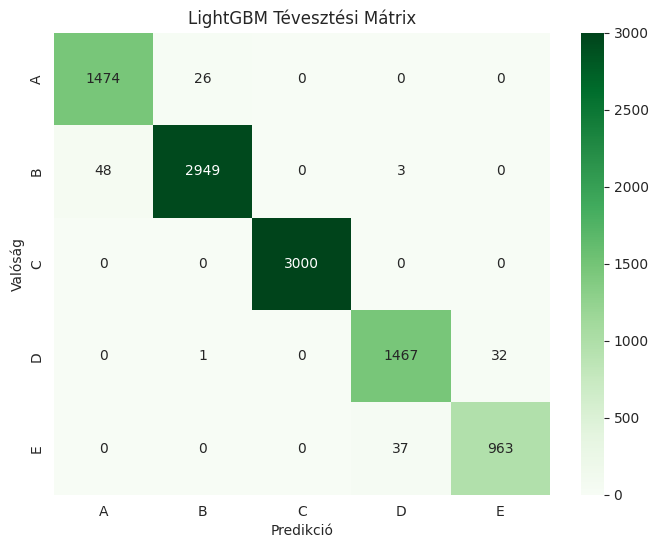

In [8]:
# ==========================================
# Eredmények vizualizációja
# ==========================================
y_pred = best_lgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"LightGBM Pontosság: {acc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Zöld színvilág a megkülönböztetéshez
            xticklabels=target_names, yticklabels=target_names)
plt.title('LightGBM Tévesztési Mátrix')
plt.xlabel('Predikció')
plt.ylabel('Valóság')
plt.show()

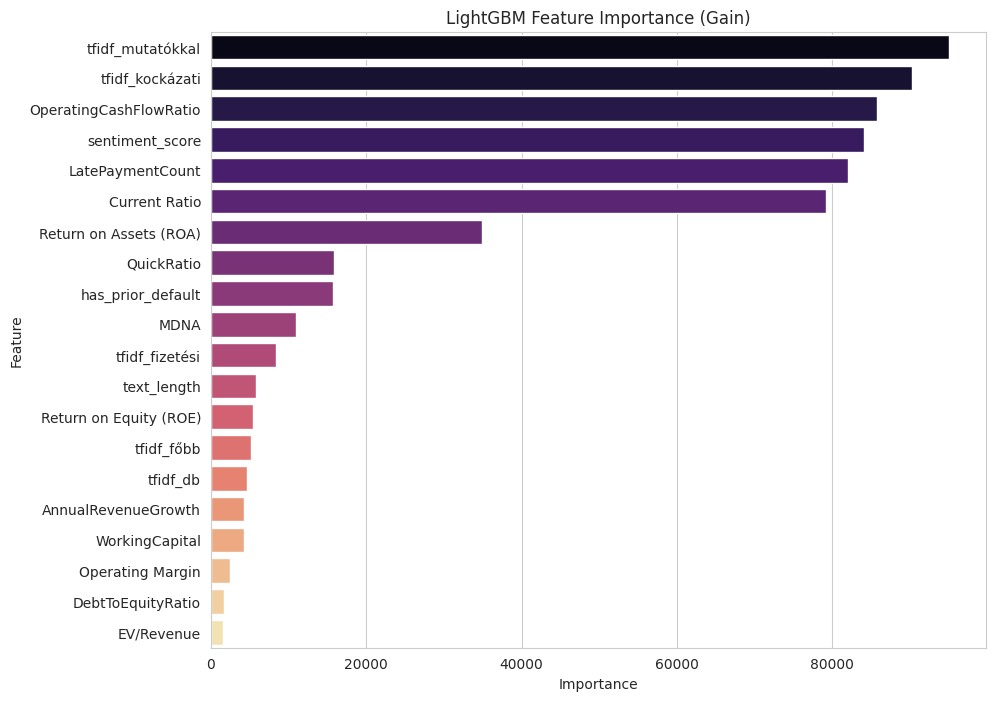


NLP Változók helyezése:


,Feature,Importance
53,tfidf_mutatókkal,95000.721218
50,tfidf_kockázati,90254.751508
37,sentiment_score,84138.705823
42,tfidf_fizetési,8338.409460
44,tfidf_főbb,5157.941996
39,tfidf_db,4660.203077


In [9]:
# ==========================================
# Feature Importance
# ==========================================
# A LightGBM-nél kétféle fontosság van: 'split' (hányszor használták vágásra) és 'gain' (mennyit javított a hibán).
# A 'gain' általában informatívabb.

importance_gain = best_lgb_model.booster_.feature_importance(importance_type='gain')
feature_names = X_train.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_gain})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('LightGBM Feature Importance (Gain)')
plt.show()

# NLP feature-ök ellenőrzése
nlp_features = [col for col in X.columns if 'sentiment' in col or 'tfidf' in col]
print("\nNLP Változók helyezése:")
nlp_ranks = fi_df[fi_df['Feature'].isin(nlp_features)]
if not nlp_ranks.empty:
    display(nlp_ranks)
else:
    print("Az NLP változók nem kerültek be a Top 20-ba.")

Shape of shap_values: (1000, 59, 5)
Shape for class E slice: (1000, 59)


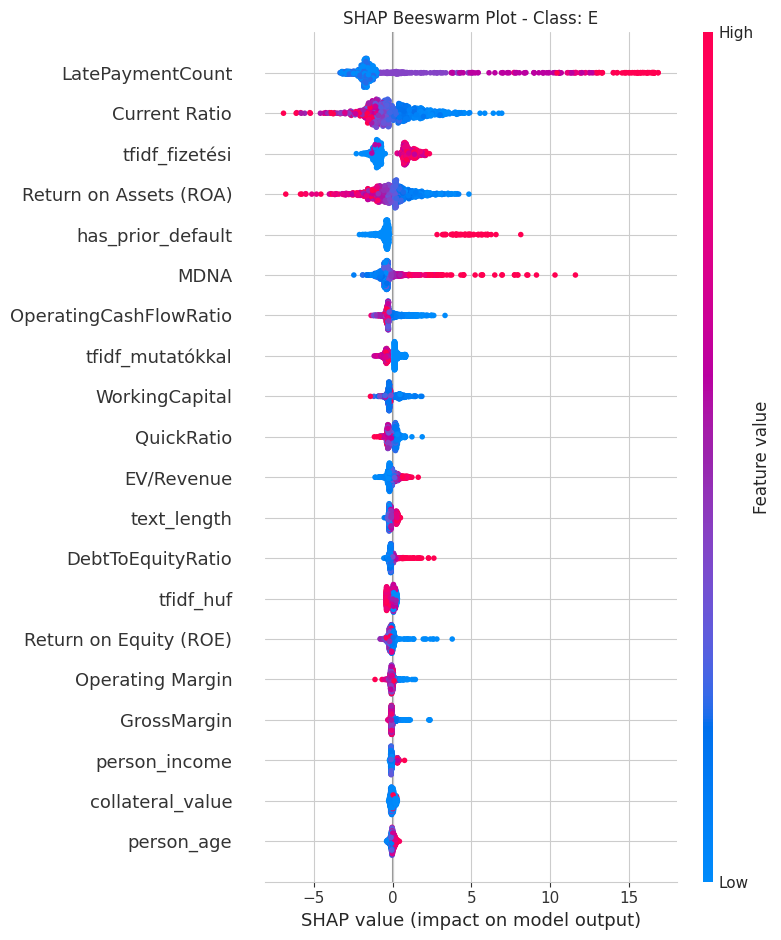

In [12]:
print(f"Shape of shap_values: {shap_values.shape}")

# Class 'E' is index 4
risk_class_idx = 4

# Extracting (samples, features) for the specific class
# shap_values is (1000, 59, 5)
shap_values_class_E = shap_values[:, :, risk_class_idx]

print(f"Shape for class E slice: {shap_values_class_E.shape}")

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Beeswarm Plot - Class: {target_names[risk_class_idx]}")
shap.summary_plot(shap_values_class_E, sample_X, show=False)
plt.show()

In [13]:
# ==========================================
# Bias Analízis
# ==========================================
results_df = X_test.copy()
results_df['True_Grade'] = y_test
results_df['Pred_Grade'] = y_pred
results_df['Is_Biased'] = bias_test

# Rossz adósok szűrése (D és E kategória)
# A LabelEncoder miatt meg kell nézni, mik ezek a kódok.
# Ha target_names = ['A', 'B', 'C', 'D', 'E'], akkor D=3, E=4.
bad_debtor_codes = [3, 4]

bad_debtors = results_df[results_df['True_Grade'].isin(bad_debtor_codes)]

acc_clean = accuracy_score(bad_debtors[bad_debtors['Is_Biased']==0]['True_Grade'],
                           bad_debtors[bad_debtors['Is_Biased']==0]['Pred_Grade'])

acc_biased = accuracy_score(bad_debtors[bad_debtors['Is_Biased']==1]['True_Grade'],
                            bad_debtors[bad_debtors['Is_Biased']==1]['Pred_Grade'])

print("\n--- LightGBM Bias Érzékenység ---")
print(f"Pontosság VALÓS leírás esetén (Rossz adósok): {acc_clean:.2%}")
print(f"Pontosság TORZÍTOTT leírás esetén (Rossz adósok): {acc_biased:.2%}")

diff = acc_clean - acc_biased
print(f"Teljesítményesés a torzítás miatt: {diff:.2%}")

if diff > 0.05:
    print("ELEMZÉS: A LightGBM modellt jelentősen befolyásolta a manipulatív szöveges leírás.")
else:
    print("ELEMZÉS: A LightGBM modell robusztusnak bizonyult, a pénzügyi mutatók domináltak.")


--- LightGBM Bias Érzékenység ---
Pontosság VALÓS leírás esetén (Rossz adósok): 97.22%
Pontosság TORZÍTOTT leírás esetén (Rossz adósok): 96.75%
Teljesítményesés a torzítás miatt: 0.48%
ELEMZÉS: A LightGBM modell robusztusnak bizonyult, a pénzügyi mutatók domináltak.
